# CAPTCHA 전용 Logistic Regression 모델 학습 및 검증

기존 `logistic_29_allow_block_type_v1.ipynb` 는 BOOKING/CAPTCHA/DETAIL 데이터를 합쳐 하나의 pooled LogReg 모델을 학습했다.
이번 노트북은 **CAPTCHA 데이터만 사용**해서 LogReg 모델을 학습한다 (type-specific 실험 3개 중 하나).

- 학습 방법 / 전처리 / 모델 파라미터는 pooled 노트북과 동일하게 유지
- 차이점은 **데이터를 CAPTCHA 으로만 제한**한 것뿐
- 본 노트북은 type 간 비교나 ensemble 분석은 포함하지 않음 — type 별로 분리된 노트북 3개 중 CAPTCHA 전용

기존 pooled LogReg 의 CAPTCHA 기준 성능 (비교용):
- CAPTCHA BLOCK Recall ≈ 0.929
- CAPTCHA FPR ≈ 0.067


## 1. 실험 설정

pooled LogReg 노트북과 **동일한 전처리 + 동일한 모델 파라미터**. 이번 실험에서는 하이퍼파라미터 튜닝을 하지 않는다.


In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
sns.set_style("whitegrid")

args = SimpleNamespace(
    TARGET_TYPE="CAPTCHA",
    RUN_VERSION="logistic_captcha_v1",
    DATA_ROOT="../../data/data_0514_1800_v2",
    MODEL_SAVE_DIR="../model_joblib/logistic_captcha_v1",
    RANDOM_STATE=42,
    TEST_SIZE=0.2,
    MAX_MISSING_RATE=0.3,
    SAVE_MODEL=True,
    # Logistic Regression 고정 파라미터 (pooled 와 동일)
    LR_C=1.0,
    LR_PENALTY="l2",
    LR_SOLVER="liblinear",
    LR_CLASS_WEIGHT="balanced",
    LR_MAX_ITER=2000,
)

# 기존 pooled LogReg 의 CAPTCHA 기준 성능
POOLED_BASELINE = {"recall_block_TPR": 0.929, "FPR": 0.067}

args


namespace(TARGET_TYPE='CAPTCHA',
          RUN_VERSION='logistic_captcha_v1',
          DATA_ROOT='../../data/data_0514_1800_v2',
          MODEL_SAVE_DIR='../model_joblib/logistic_captcha_v1',
          RANDOM_STATE=42,
          TEST_SIZE=0.2,
          MAX_MISSING_RATE=0.3,
          SAVE_MODEL=True,
          LR_C=1.0,
          LR_PENALTY='l2',
          LR_SOLVER='liblinear',
          LR_CLASS_WEIGHT='balanced',
          LR_MAX_ITER=2000)

## 2. 데이터 로드 및 CAPTCHA 필터

전체 데이터를 로드한 뒤 `type == "CAPTCHA"` 데이터만 추출. 경로 기준으로 `type / label_norm / y` 생성.


In [2]:
TYPE_MAP = {"booking": "BOOKING", "captcha": "CAPTCHA", "detail": "DETAIL"}
LABEL_MAP = {"allow": "ALLOW", "block": "BLOCK"}


def _match_from_parts(parts_lower, mapping):
    return [v for k, v in mapping.items() if k in parts_lower]


def load_data(root_dir):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {root.resolve()}")
    rows = []
    n_total, n_skip = 0, 0
    for jp in sorted(root.rglob("*.json")):
        n_total += 1
        try:
            with open(jp, encoding="utf-8") as f:
                obj = json.load(f)
        except Exception as e:
            warnings.warn(f"skip {jp}: {e}")
            n_skip += 1
            continue
        flat = pd.json_normalize(obj, sep=".")
        flat.columns = [c.split(".", 1)[1] if c.startswith("metrics.") else c for c in flat.columns]
        parts_lower = [p.lower() for p in jp.parts]
        type_hits = _match_from_parts(parts_lower, TYPE_MAP)
        label_hits = _match_from_parts(parts_lower, LABEL_MAP)
        if len(type_hits) != 1:
            raise ValueError(f"{jp}: type matches {type_hits}")
        if len(label_hits) != 1:
            raise ValueError(f"{jp}: label matches {label_hits}")
        flat["type"] = type_hits[0]
        flat["label_norm"] = label_hits[0]
        flat["y"] = 0 if label_hits[0] == "ALLOW" else 1
        flat["source_path"] = str(jp)
        flat["source_file"] = jp.name
        rows.append(flat)
    df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    _NON_NUMERIC_META = {"type", "label_norm", "source_path", "source_file", "label"}
    for _c in df.columns:
        if _c in _NON_NUMERIC_META or _c == "y":
            continue
        if df[_c].dtype == object:
            df[_c] = pd.to_numeric(df[_c], errors="coerce")
    return df, n_total, n_skip


In [3]:
df_all, n_total, n_skip = load_data(args.DATA_ROOT)
print(f"json files scanned: {n_total}, skipped: {n_skip}, loaded rows: {len(df_all)}")
print(f"df_all.shape: {df_all.shape}")

# CAPTCHA 데이터만 필터링
df_eda = df_all[df_all["type"] == args.TARGET_TYPE].reset_index(drop=True)
print(f"\nafter filter (type=={args.TARGET_TYPE}): df_eda.shape = {df_eda.shape}")
print(f"columns ({len(df_eda.columns)}):", df_eda.columns.tolist()[:50])

n_allow = int((df_eda["label_norm"] == "ALLOW").sum())
n_block = int((df_eda["label_norm"] == "BLOCK").sum())
print(f"\n[CAPTCHA] n_total={len(df_eda)}, ALLOW={n_allow}, BLOCK={n_block}, block_ratio={n_block / len(df_eda):.4f}")

if n_allow < 30 or n_block < 30:
    warnings.warn(f"small class size: ALLOW={n_allow}, BLOCK={n_block}")

if df_eda["y"].nunique() < 2:
    raise RuntimeError(f"only one class present for type={args.TARGET_TYPE} — cannot train")


json files scanned: 707, skipped: 0, loaded rows: 707
df_all.shape: (707, 41)

after filter (type==CAPTCHA): df_eda.shape = (238, 41)
columns (41): ['trialId', 'label', 'type', 'reclick_rate', 'misclick_rate', 'mouse_jerk_mean', 'double_click_rate', 'mouse_overshoot_flag', 'mousemove_event_rate', 'pre_click_scroll_flag', 'time_to_first_click_ms', 'inter_click_interval_ms', 'mouse_acceleration_mean', 'mouse_speed_change_mean', 'pre_click_hover_time_ms', 'click_offset_variance_px', 'mouse_stop_segment_count', 'mouse_avg_speed_px_per_ms', 'mouse_hover_dwell_time_ms', 'mouse_max_speed_px_per_ms', 'mouse_path_curvature_mean', 'pre_click_mousemove_count', 'click_position_repeat_rate', 'mouse_direction_change_count', 'mouse_path_straightness_score', 'edge_or_fixed_point_visit_rate', 'mouse_total_travel_distance_px', 'click_sequence_consistency_score', 'immediate_post_render_click_rate', 'pre_click_path_300ms_straightness', 'pre_click_path_500ms_straightness', 'inter_element_move_interval_std_

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_11644\4157326292.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


## 3. Feature 준비

숫자형 컬럼만 후보로 사용. 다음 컬럼 제외:
- y / label_norm / type / source_path / source_file
- id / trial_id / trialId / user_id / session_id
- timestamp / created_at / updated_at 포함 컬럼

`MAX_MISSING_RATE = 0.3` 이상 결측 + CAPTCHA 데이터에서 전부 결측인 feature 는 제외.


In [4]:
EXCLUDE_EXACT = {
    "y", "label_norm", "type", "source_path", "source_file",
    "id", "trial_id", "trialId", "user_id", "session_id",
}
EXCLUDE_SUBSTR = ("timestamp", "created_at", "updated_at")


def is_excluded(col):
    if col in EXCLUDE_EXACT:
        return True
    c = col.lower()
    return any(s in c for s in EXCLUDE_SUBSTR)


numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
feature_candidates = [c for c in numeric_cols if not is_excluded(c)]

print(f"numeric columns: {len(numeric_cols)}")
print(f"feature_candidates: {len(feature_candidates)}")


numeric columns: 36
feature_candidates: 34


In [5]:
missing_rate = df_eda[feature_candidates].isna().mean().sort_values(ascending=False)
print("[missing rate per feature]")
print(missing_rate.to_string())

excluded_by_missing = [c for c in feature_candidates if missing_rate[c] > args.MAX_MISSING_RATE]
excluded_all_missing = [c for c in feature_candidates if missing_rate[c] >= 1.0]
selected_features = [c for c in feature_candidates if c not in excluded_by_missing]

print(f"\nMAX_MISSING_RATE = {args.MAX_MISSING_RATE}")
print(f"excluded_by_missing ({len(excluded_by_missing)}): {excluded_by_missing}")
if excluded_all_missing:
    warnings.warn(f"all-missing features (subset of excluded_by_missing): {excluded_all_missing}")
print(f"selected_features ({len(selected_features)}):")
for c in selected_features:
    print(f"  - {c}")


[missing rate per feature]
mouse_jerk_mean                            0.621849
inter_element_move_interval_std_ms         0.004202
misclick_rate                              0.000000
reclick_rate                               0.000000
mouse_overshoot_flag                       0.000000
double_click_rate                          0.000000
pre_click_scroll_flag                      0.000000
time_to_first_click_ms                     0.000000
inter_click_interval_ms                    0.000000
mousemove_event_rate                       0.000000
mouse_speed_change_mean                    0.000000
pre_click_hover_time_ms                    0.000000
click_offset_variance_px                   0.000000
mouse_stop_segment_count                   0.000000
mouse_avg_speed_px_per_ms                  0.000000
mouse_hover_dwell_time_ms                  0.000000
mouse_max_speed_px_per_ms                  0.000000
mouse_acceleration_mean                    0.000000
mouse_path_curvature_mean            

## 4. Train / Test Split

`test_size=0.2`, `stratify=y`, `random_state=42`.


In [6]:
X = df_eda[selected_features].copy()
y = df_eda["y"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=args.TEST_SIZE,
    random_state=args.RANDOM_STATE,
    stratify=y,
)

print(f"X_train.shape: {X_train.shape}, X_test.shape: {X_test.shape}")
print("\n[train label distribution]")
print(y_train.value_counts().sort_index())
print("\n[test label distribution]")
print(y_test.value_counts().sort_index())


X_train.shape: (190, 33), X_test.shape: (48, 33)

[train label distribution]
y
0     69
1    121
Name: count, dtype: int64

[test label distribution]
y
0    18
1    30
Name: count, dtype: int64


## 5. Pipeline 학습

`SimpleImputer(median)` → `StandardScaler` → `LogisticRegression(C=1.0, l2, liblinear, balanced, max_iter=2000)`.


In [7]:
lr_model = LogisticRegression(
    C=args.LR_C,
    penalty=args.LR_PENALTY,
    solver=args.LR_SOLVER,
    class_weight=args.LR_CLASS_WEIGHT,
    max_iter=args.LR_MAX_ITER,
    random_state=args.RANDOM_STATE,
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", lr_model),
])

t0 = time.time()
pipeline.fit(X_train, y_train)
fit_sec = time.time() - t0
print(f"학습 완료 — fit time: {fit_sec:.2f}s")
print(f"train accuracy: {pipeline.score(X_train, y_train):.4f}")
print(f"test  accuracy: {pipeline.score(X_test, y_test):.4f}")
pipeline


학습 완료 — fit time: 0.01s
train accuracy: 0.9947
test  accuracy: 0.9375


,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


## 6. 모델 검증 (threshold=0.5)

기존 pooled LogReg 의 CAPTCHA 기준 recall ≈ 0.929, FPR ≈ 0.067 과 비교.


In [8]:
y_pred = pipeline.predict(X_test)
y_proba_block = pipeline.predict_proba(X_test)[:, 1]


def safe_metric(fn, y_true, y_score):
    try:
        if pd.Series(y_true).nunique() < 2:
            return np.nan
        return float(fn(y_true, y_score))
    except Exception:
        return np.nan


def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return {
        "n_samples": int(len(y_true)),
        "n_allow": int((np.asarray(y_true) == 0).sum()),
        "n_block": int((np.asarray(y_true) == 1).sum()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_block_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_metric(roc_auc_score, y_true, y_score),
        "average_precision": safe_metric(average_precision_score, y_true, y_score),
        "FPR": fpr,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


overall_metrics = compute_metrics(y_test.values, y_pred, y_proba_block)
for k, v in overall_metrics.items():
    print(f"  {k}: {v}")

print("\n[confusion matrix]  [[tn fp][fn tp]]")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

print("\n[classification report]")
print(classification_report(y_test, y_pred, target_names=["ALLOW", "BLOCK"], digits=4))


  n_samples: 48
  n_allow: 18
  n_block: 30
  accuracy: 0.9375
  precision: 0.9090909090909091
  recall_block_TPR: 1.0
  f1: 0.9523809523809523
  roc_auc: 0.9481481481481482
  average_precision: 0.9399145703834616
  FPR: 0.16666666666666666
  tn: 15
  fp: 3
  fn: 0
  tp: 30

[confusion matrix]  [[tn fp][fn tp]]
[[15  3]
 [ 0 30]]

[classification report]
              precision    recall  f1-score   support

       ALLOW     1.0000    0.8333    0.9091        18
       BLOCK     0.9091    1.0000    0.9524        30

    accuracy                         0.9375        48
   macro avg     0.9545    0.9167    0.9307        48
weighted avg     0.9432    0.9375    0.9361        48



In [9]:
# pooled baseline 비교 (단일 type)
recall = overall_metrics["recall_block_TPR"]
fpr_val = overall_metrics["FPR"]
recall_diff = recall - POOLED_BASELINE["recall_block_TPR"]
fpr_diff = fpr_val - POOLED_BASELINE["FPR"]

print(f"=== pooled CAPTCHA baseline 비교 ===")
print(f"  pooled recall = {POOLED_BASELINE['recall_block_TPR']:.4f}  →  type-specific recall = {recall:.4f}  (diff = {recall_diff:+.4f})")
print(f"  pooled FPR    = {POOLED_BASELINE['FPR']:.4f}  →  type-specific FPR    = {fpr_val:.4f}  (diff = {fpr_diff:+.4f})")

better_recall = recall >= POOLED_BASELINE["recall_block_TPR"]
better_fpr = fpr_val <= POOLED_BASELINE["FPR"]
print(f"  better_than_pooled_recall: {better_recall}")
print(f"  better_than_pooled_FPR   : {better_fpr}")


=== pooled CAPTCHA baseline 비교 ===
  pooled recall = 0.9290  →  type-specific recall = 1.0000  (diff = +0.0710)
  pooled FPR    = 0.0670  →  type-specific FPR    = 0.1667  (diff = +0.0997)
  better_than_pooled_recall: True
  better_than_pooled_FPR   : False


## 7. Threshold Sweep

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

추천 threshold: recall ≥ 0.9 인 threshold 중 FPR 최소. 동률이면 0.5 에 가까운 값. 모두 recall<0.9 면 0.5 사용 + warning.


In [10]:
THRESHOLDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

threshold_rows = []
for thr in THRESHOLDS:
    y_pred_thr = (y_proba_block >= thr).astype(int)
    m = compute_metrics(y_test.values, y_pred_thr, y_proba_block)
    threshold_rows.append({
        "threshold": thr,
        "accuracy": m["accuracy"], "precision": m["precision"],
        "recall_block_TPR": m["recall_block_TPR"], "f1": m["f1"],
        "FPR": m["FPR"],
        "tn": m["tn"], "fp": m["fp"], "fn": m["fn"], "tp": m["tp"],
    })

threshold_results_df = pd.DataFrame(threshold_rows)
print("[threshold_results_df]")
print(threshold_results_df.to_string(index=False))


[threshold_results_df]
 threshold  accuracy  precision  recall_block_TPR       f1      FPR  tn  fp  fn  tp
       0.2  0.895833   0.857143          1.000000 0.923077 0.277778  13   5   0  30
       0.3  0.916667   0.882353          1.000000 0.937500 0.222222  14   4   0  30
       0.4  0.916667   0.882353          1.000000 0.937500 0.222222  14   4   0  30
       0.5  0.937500   0.909091          1.000000 0.952381 0.166667  15   3   0  30
       0.6  0.937500   0.909091          1.000000 0.952381 0.166667  15   3   0  30
       0.7  0.916667   0.906250          0.966667 0.935484 0.166667  15   3   1  29
       0.8  0.958333   0.966667          0.966667 0.966667 0.055556  17   1   1  29


In [11]:
def pick_threshold(df_sweep, recall_floor=0.9, default_thr=0.5):
    cand = df_sweep[df_sweep["recall_block_TPR"] >= recall_floor]
    if cand.empty:
        warnings.warn(f"no threshold meets recall>={recall_floor} → use default {default_thr}")
        return default_thr
    min_fpr = cand["FPR"].min()
    best = cand[cand["FPR"] == min_fpr]
    chosen = best.iloc[(best["threshold"] - default_thr).abs().argsort()].iloc[0]
    return float(chosen["threshold"])


selected_threshold = pick_threshold(threshold_results_df)
sel_row = threshold_results_df[threshold_results_df["threshold"] == selected_threshold].iloc[0]
print(f"추천 threshold = {selected_threshold:.2f}")
print(f"  recall={sel_row['recall_block_TPR']:.4f}, FPR={sel_row['FPR']:.4f}, "
      f"precision={sel_row['precision']:.4f}, f1={sel_row['f1']:.4f}")


추천 threshold = 0.80
  recall=0.9667, FPR=0.0556, precision=0.9667, f1=0.9667


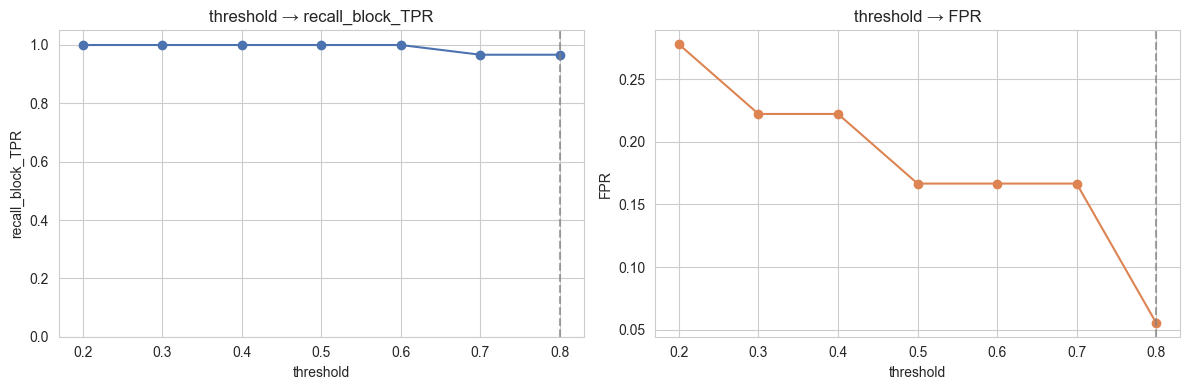

In [12]:
# threshold lineplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sub = threshold_results_df.sort_values("threshold")

axes[0].plot(sub["threshold"], sub["recall_block_TPR"], marker="o", color="#4C72B0")
axes[0].axvline(selected_threshold, ls="--", color="gray", alpha=0.7)
axes[0].set_title("threshold → recall_block_TPR")
axes[0].set_xlabel("threshold"); axes[0].set_ylabel("recall_block_TPR"); axes[0].set_ylim(0, 1.05)

axes[1].plot(sub["threshold"], sub["FPR"], marker="o", color="#DD8452")
axes[1].axvline(selected_threshold, ls="--", color="gray", alpha=0.7)
axes[1].set_title("threshold → FPR")
axes[1].set_xlabel("threshold"); axes[1].set_ylabel("FPR")

plt.tight_layout()
plt.show()


## 8. Probability Distribution

CAPTCHA test set 의 P_BLOCK 분포. `separation_margin = block_q25 - allow_q75` 가 양수면 분포가 잘 분리됨, 음수면 겹침.


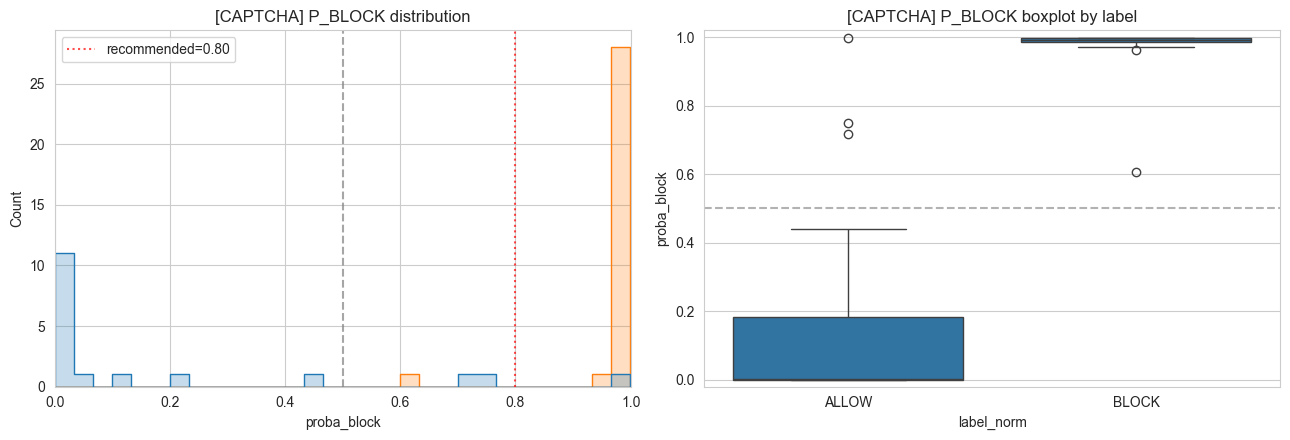

In [13]:
prediction_df = pd.DataFrame({
    "y_true": y_test.values,
    "label_norm": np.where(y_test.values == 1, "BLOCK", "ALLOW"),
    "proba_block": y_proba_block,
    "y_pred_0_5": y_pred,
})

# histogram (ALLOW/BLOCK overlay) + boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
sns.histplot(data=prediction_df, x="proba_block", hue="label_norm",
             bins=30, kde=False, element="step", stat="count", ax=ax,
             hue_order=["ALLOW", "BLOCK"], common_norm=False)
ax.axvline(0.5, ls="--", color="gray", alpha=0.7)
ax.axvline(selected_threshold, ls=":", color="red", alpha=0.7, label=f"recommended={selected_threshold:.2f}")
ax.legend()
ax.set_title("[CAPTCHA] P_BLOCK distribution")
ax.set_xlim(0, 1)

ax = axes[1]
sns.boxplot(data=prediction_df, x="label_norm", y="proba_block",
            order=["ALLOW", "BLOCK"], ax=ax)
ax.axhline(0.5, ls="--", color="gray", alpha=0.6)
ax.set_title("[CAPTCHA] P_BLOCK boxplot by label")
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()


In [14]:
a = y_proba_block[y_test.values == 0]
b = y_proba_block[y_test.values == 1]
n_a, n_b = len(a), len(b)

probability_separation = {
    "n_allow": int(n_a),
    "n_block": int(n_b),
    "allow_proba_mean": float(np.nanmean(a)) if n_a else np.nan,
    "block_proba_mean": float(np.nanmean(b)) if n_b else np.nan,
    "allow_proba_median": float(np.nanmedian(a)) if n_a else np.nan,
    "block_proba_median": float(np.nanmedian(b)) if n_b else np.nan,
    "allow_q75": float(np.nanquantile(a, 0.75)) if n_a else np.nan,
    "block_q25": float(np.nanquantile(b, 0.25)) if n_b else np.nan,
    "roc_auc": safe_metric(roc_auc_score, y_test.values, y_proba_block),
    "average_precision": safe_metric(average_precision_score, y_test.values, y_proba_block),
}
probability_separation["proba_gap_mean"] = (
    probability_separation["block_proba_mean"] - probability_separation["allow_proba_mean"]
)
probability_separation["proba_gap_median"] = (
    probability_separation["block_proba_median"] - probability_separation["allow_proba_median"]
)
probability_separation["separation_margin"] = (
    probability_separation["block_q25"] - probability_separation["allow_q75"]
)

probability_separation_df = pd.DataFrame([probability_separation])[[
    "n_allow", "n_block",
    "allow_proba_mean", "block_proba_mean", "proba_gap_mean",
    "allow_proba_median", "block_proba_median", "proba_gap_median",
    "allow_q75", "block_q25", "separation_margin",
    "roc_auc", "average_precision",
]]
print("[probability_separation_df]")
print(probability_separation_df.to_string(index=False))

sm = probability_separation["separation_margin"]
flag = "✅ 분리 양호" if sm > 0 else "⚠ 분포 겹침"
print(f"\nseparation_margin = {sm:+.4f}  → {flag}")


[probability_separation_df]
 n_allow  n_block  allow_proba_mean  block_proba_mean  proba_gap_mean  allow_proba_median  block_proba_median  proba_gap_median  allow_q75  block_q25  separation_margin  roc_auc  average_precision
      18       30          0.182257          0.977784        0.795528            0.001073            0.993319          0.992246   0.183745   0.987054           0.803309 0.948148           0.939915

separation_margin = +0.8033  → ✅ 분리 양호


## 9. Coefficient Analysis

Pipeline 에 StandardScaler 가 포함되어 있으므로 coefficient 는 표준화된 feature 기준의 영향력. coefficient > 0 → feature 가 클수록 BLOCK 확률 ↑, coefficient < 0 → ALLOW 확률 ↑.


In [15]:
coef = pipeline.named_steps["model"].coef_[0]
intercept = float(pipeline.named_steps["model"].intercept_[0])

coefficient_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef),
    "direction": np.where(coef >= 0, "BLOCK+", "ALLOW-"),
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

print(f"intercept = {intercept:.4f}")
print(f"\n[CAPTCHA] abs_coefficient top 20")
print(coefficient_df.head(20).to_string(index=False))

pos = coefficient_df[coefficient_df["coefficient"] > 0].sort_values("coefficient", ascending=False).head(15)
neg = coefficient_df[coefficient_df["coefficient"] < 0].sort_values("coefficient", ascending=True).head(15)
print(f"\n[CAPTCHA] BLOCK+ positive coefficient top 15")
print(pos[["feature", "coefficient"]].to_string(index=False))
print(f"\n[CAPTCHA] ALLOW- negative coefficient top 15")
print(neg[["feature", "coefficient"]].to_string(index=False))


intercept = 0.4003

[CAPTCHA] abs_coefficient top 20
                               feature  coefficient  abs_coefficient direction
     pre_click_path_300ms_straightness    -1.223317         1.223317    ALLOW-
               mouse_speed_change_mean     1.003093         1.003093    BLOCK+
pre_click_path_300ms_total_distance_px    -0.899058         0.899058    ALLOW-
                         misclick_rate    -0.805899         0.805899    ALLOW-
                  mouse_overshoot_flag     0.712884         0.712884    BLOCK+
          mouse_direction_change_count    -0.707374         0.707374    ALLOW-
                     double_click_rate     0.703673         0.703673    BLOCK+
             pre_click_mousemove_count    -0.693337         0.693337    ALLOW-
                  mousemove_event_rate    -0.664857         0.664857    ALLOW-
              click_offset_variance_px     0.584814         0.584814    BLOCK+
               inter_click_interval_ms    -0.514345         0.514345    ALLOW-

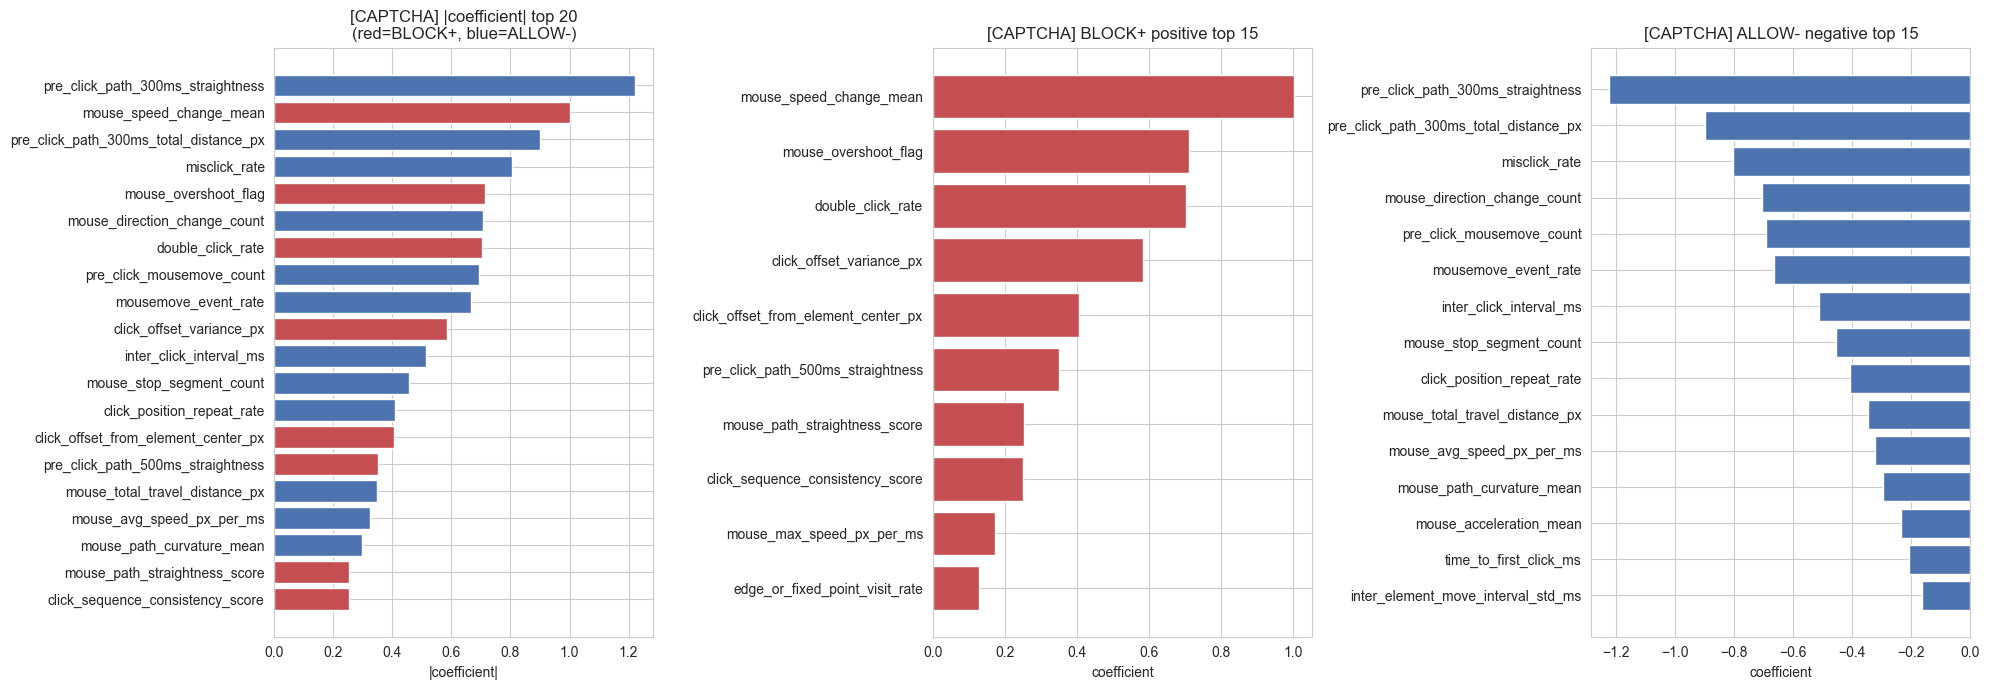

In [16]:
# 시각화 — abs_coefficient top 20 + positive top 15 + negative top 15
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# abs top 20 (양/음 색상)
top20 = coefficient_df.head(20).iloc[::-1]
colors = ["#C44E52" if d == "BLOCK+" else "#4C72B0" for d in top20["direction"]]
axes[0].barh(top20["feature"], top20["abs_coefficient"], color=colors)
axes[0].set_title("[CAPTCHA] |coefficient| top 20\n(red=BLOCK+, blue=ALLOW-)")
axes[0].set_xlabel("|coefficient|")

# positive top 15
pos_plot = coefficient_df[coefficient_df["coefficient"] > 0].sort_values("coefficient", ascending=True).tail(15)
axes[1].barh(pos_plot["feature"], pos_plot["coefficient"], color="#C44E52")
axes[1].set_title("[CAPTCHA] BLOCK+ positive top 15")
axes[1].set_xlabel("coefficient")

# negative top 15
neg_plot = coefficient_df[coefficient_df["coefficient"] < 0].sort_values("coefficient", ascending=False).tail(15)
axes[2].barh(neg_plot["feature"], neg_plot["coefficient"], color="#4C72B0")
axes[2].set_title("[CAPTCHA] ALLOW- negative top 15")
axes[2].set_xlabel("coefficient")

plt.tight_layout()
plt.show()


## 10. 모델 저장

기존 `model_joblib/logistic_29_allow_block_type_v1/` 폴더의 컨벤션과 동일하게 3개 파일만 저장:

- `model.joblib` — LogReg Pipeline 객체
- `meta.json`    — 설정 / feature_names / model_params / coefficient_top / selected_threshold
- `metrics.json` — overall metrics / threshold_sweep / probability_separation

저장 위치: `model_joblib/logistic_captcha_v1/`. csv / png / md / html 저장 금지.


In [17]:
import json as _json_mod
from datetime import datetime


def _json_safe(x):
    if isinstance(x, dict):
        return {str(k): _json_safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [_json_safe(v) for v in x]
    if isinstance(x, np.ndarray):
        return [_json_safe(v) for v in x.tolist()]
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.floating):
        f = float(x)
        return None if f != f else f
    if isinstance(x, np.bool_):
        return bool(x)
    if isinstance(x, float):
        return None if x != x else x
    return x


if args.SAVE_MODEL:
    os.makedirs(args.MODEL_SAVE_DIR, exist_ok=True)

    # 1) model.joblib — Pipeline 전체
    model_path = os.path.join(args.MODEL_SAVE_DIR, "model.joblib")
    joblib.dump(pipeline, model_path)

    # 2) meta.json — 설정 / feature / coefficient / threshold 정책
    meta = {
        "model_name": args.RUN_VERSION,
        "run_version": args.RUN_VERSION,
        "model_type": "LogisticRegression",
        "target_type": args.TARGET_TYPE,
        "trained_at": datetime.now().isoformat(timespec="seconds"),
        "label_mapping": {"ALLOW": 0, "BLOCK": 1},
        "feature_names": selected_features,
        "n_features": len(selected_features),
        "excluded_by_missing": excluded_by_missing,
        "dataset": {
            "data_root": args.DATA_ROOT,
            "target_type": args.TARGET_TYPE,
            "test_size": args.TEST_SIZE,
            "random_state": args.RANDOM_STATE,
            "max_missing_rate": args.MAX_MISSING_RATE,
            "n_train": int(len(X_train)),
            "n_test": int(len(X_test)),
        },
        "model_params": pipeline.named_steps["model"].get_params(),
        "intercept": intercept,
        "coefficient_top_features": coefficient_df.head(20).to_dict("records"),
        "pooled_baseline": POOLED_BASELINE,
        "deployment": {
            "positive_class": "BLOCK",
            "positive_class_index": 1,
            "decision_rule": "predict BLOCK if predict_proba(X)[:, 1] >= threshold",
            "default_threshold": 0.5,
            "selected_threshold": selected_threshold,
            "selection_rule": "recall>=0.9 then min FPR, tie-break by closest to 0.5",
            "routing_note": f"This model is valid ONLY for type == {args.TARGET_TYPE}. Use the matching type-specific model for other types.",
        },
    }
    meta_path = os.path.join(args.MODEL_SAVE_DIR, "meta.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        _json_mod.dump(_json_safe(meta), f, ensure_ascii=False, indent=2)

    # 3) metrics.json — 평가 지표
    pooled_comparison = {
        "pooled_recall_baseline": POOLED_BASELINE["recall_block_TPR"],
        "type_specific_recall": overall_metrics["recall_block_TPR"],
        "recall_diff": overall_metrics["recall_block_TPR"] - POOLED_BASELINE["recall_block_TPR"],
        "pooled_FPR_baseline": POOLED_BASELINE["FPR"],
        "type_specific_FPR": overall_metrics["FPR"],
        "FPR_diff": overall_metrics["FPR"] - POOLED_BASELINE["FPR"],
        "better_than_pooled_recall": bool(overall_metrics["recall_block_TPR"] >= POOLED_BASELINE["recall_block_TPR"]),
        "better_than_pooled_FPR": bool(overall_metrics["FPR"] <= POOLED_BASELINE["FPR"]),
    }

    metrics_data = {
        "target_type": args.TARGET_TYPE,
        "overall": overall_metrics,
        "threshold_sweep": threshold_results_df.to_dict("records"),
        "probability_separation": probability_separation,
        "pooled_baseline_comparison": pooled_comparison,
    }
    metrics_path = os.path.join(args.MODEL_SAVE_DIR, "metrics.json")
    with open(metrics_path, "w", encoding="utf-8") as f:
        _json_mod.dump(_json_safe(metrics_data), f, ensure_ascii=False, indent=2)

    print("saved:")
    print(f"  {os.path.abspath(model_path)}")
    print(f"  {os.path.abspath(meta_path)}")
    print(f"  {os.path.abspath(metrics_path)}")
else:
    print("SAVE_MODEL=False — skip saving")


saved:
  c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\logistic_captcha_v1\model.joblib
  c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\logistic_captcha_v1\meta.json
  c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_joblib\logistic_captcha_v1\metrics.json


## 11. 추론 helper 예시

이 모델은 `CAPTCHA` 데이터에만 유효. 다른 type 데이터에 적용하면 안 됨 (별도의 type-specific 모델 사용).


In [18]:
def predict_sample(X_sample, pipeline, feature_names, threshold=0.5):
    """X_sample: DataFrame row(s) — column 정렬을 위해 reindex.

    NOTE: 호출자가 X_sample 이 CAPTCHA 데이터인지 보장해야 한다.
    type 검증은 모델 외부 routing 단계에서 수행.
    """
    X = X_sample.reindex(columns=feature_names)
    proba_block = pipeline.predict_proba(X)[:, 1]
    y_hat = (proba_block >= threshold).astype(int)
    label_pred = np.where(y_hat == 1, "BLOCK", "ALLOW")
    return {
        "proba_block": proba_block,
        "threshold": threshold,
        "y_pred": y_hat,
        "label_pred": label_pred,
    }


# 동작 sanity check — test set 상위 5건
_X = X_test.head(5)
_out = predict_sample(_X, pipeline, selected_features, threshold=selected_threshold)
print(f"[sanity check — n=5, threshold={selected_threshold:.2f}]")
print(pd.DataFrame({
    "proba_block": _out["proba_block"],
    "y_pred": _out["y_pred"],
    "label_pred": _out["label_pred"],
    "y_true": y_test.head(5).values,
    "true_label": np.where(y_test.head(5).values == 1, "BLOCK", "ALLOW"),
}))


[sanity check — n=5, threshold=0.80]
   proba_block  y_pred label_pred  y_true true_label
0     0.003444       0      ALLOW       0      ALLOW
1     0.046208       0      ALLOW       0      ALLOW
2     0.000043       0      ALLOW       0      ALLOW
3     0.001335       0      ALLOW       0      ALLOW
4     0.000454       0      ALLOW       0      ALLOW


## 12. 자동 요약 리포트


In [19]:
print("=" * 70)
print(f"[CAPTCHA] Logistic Regression — 자동 요약")
print("=" * 70)

# 1. 성능
print("\n=== 1. 모델 성능 (threshold=0.5) ===")
print(f"  recall_block_TPR  : {overall_metrics['recall_block_TPR']:.4f}")
print(f"  FPR               : {overall_metrics['FPR']:.4f}")
print(f"  precision         : {overall_metrics['precision']:.4f}")
print(f"  f1                : {overall_metrics['f1']:.4f}")
print(f"  roc_auc           : {overall_metrics['roc_auc']:.4f}")
print(f"  average_precision : {overall_metrics['average_precision']:.4f}")
print(f"  n_train / n_test  : {len(X_train)} / {len(X_test)}  "
      f"(test allow={overall_metrics['n_allow']}, block={overall_metrics['n_block']})")
print(f"  n_features        : {len(selected_features)}")

# 2. pooled 비교
print("\n=== 2. pooled CAPTCHA baseline 대비 ===")
print(f"  pooled recall = {POOLED_BASELINE['recall_block_TPR']:.4f}  →  type-specific = {recall:.4f}  "
      f"(diff = {recall_diff:+.4f}, {'↑' if recall_diff > 0 else '↓' if recall_diff < 0 else '='})")
print(f"  pooled FPR    = {POOLED_BASELINE['FPR']:.4f}  →  type-specific = {fpr_val:.4f}  "
      f"(diff = {fpr_diff:+.4f}, {'↓' if fpr_diff < 0 else '↑' if fpr_diff > 0 else '='})")

# 3. 분리도
print("\n=== 3. P_BLOCK 분리도 ===")
print(f"  separation_margin = block_q25 - allow_q75 = {probability_separation['separation_margin']:+.4f}")
print(f"  → {'✅ 분리 양호' if probability_separation['separation_margin'] > 0 else '⚠ 분포 겹침'}")

# 4. 추천 threshold
print("\n=== 4. 추천 threshold ===")
print(f"  selected_threshold = {selected_threshold:.2f}  "
      f"(recall={sel_row['recall_block_TPR']:.4f}, FPR={sel_row['FPR']:.4f})")

# 5. coefficient 요약
print("\n=== 5. coefficient 기준 주요 feature top 5 ===")
print(coefficient_df.head(5)[["feature", "coefficient", "direction"]].to_string(index=False))

# 6. verdict
print("\n=== 6. 채택 verdict ===")
verdicts = []
if recall_diff >= 0 and fpr_diff <= 0:
    verdicts.append(f"[CAPTCHA] type-specific 가 pooled 대비 recall ≥ 0 AND FPR ≤ 0 → 채택 후보")
elif recall_diff < 0 and fpr_diff > 0:
    verdicts.append(f"[CAPTCHA] type-specific 가 pooled 대비 recall ↓ AND FPR ↑ → pooled 가 안정적")
elif recall_diff >= 0 and fpr_diff > 0:
    verdicts.append(f"[CAPTCHA] recall 은 같거나 좋지만 FPR ↑ → recall 우선 정책일 때만 후보")
else:  # recall_diff < 0 and fpr_diff <= 0
    verdicts.append(f"[CAPTCHA] recall 은 떨어졌지만 FPR 개선 → 운영 안정성 우선 정책일 때 후보")

if probability_separation["separation_margin"] > 0:
    verdicts.append(f"[CAPTCHA] separation_margin > 0 → 분포 분리가 양호, threshold 조정으로 운영점 유연")
else:
    verdicts.append(f"[CAPTCHA] separation_margin <= 0 → 분포 겹침, threshold 조정 효과 제한적")

for v in verdicts:
    print(f"  - {v}")

print("\n" + "=" * 70)
print("리포트 끝")
print("=" * 70)


[CAPTCHA] Logistic Regression — 자동 요약

=== 1. 모델 성능 (threshold=0.5) ===
  recall_block_TPR  : 1.0000
  FPR               : 0.1667
  precision         : 0.9091
  f1                : 0.9524
  roc_auc           : 0.9481
  average_precision : 0.9399
  n_train / n_test  : 190 / 48  (test allow=18, block=30)
  n_features        : 33

=== 2. pooled CAPTCHA baseline 대비 ===
  pooled recall = 0.9290  →  type-specific = 1.0000  (diff = +0.0710, ↑)
  pooled FPR    = 0.0670  →  type-specific = 0.1667  (diff = +0.0997, ↑)

=== 3. P_BLOCK 분리도 ===
  separation_margin = block_q25 - allow_q75 = +0.8033
  → ✅ 분리 양호

=== 4. 추천 threshold ===
  selected_threshold = 0.80  (recall=0.9667, FPR=0.0556)

=== 5. coefficient 기준 주요 feature top 5 ===
                               feature  coefficient direction
     pre_click_path_300ms_straightness    -1.223317    ALLOW-
               mouse_speed_change_mean     1.003093    BLOCK+
pre_click_path_300ms_total_distance_px    -0.899058    ALLOW-
                      